# Home Credit Default Risk Predictor
## Hyperparameter Tuning

## 1. Imports & Configuration

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    StratifiedKFold
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    RocCurveDisplay
)
from scipy.stats import randint, uniform, loguniform

RANDOM_STATE = 42
TEST_SIZE = 0.2
SCORING = 'roc_auc'
N_ITER = 15
CV_FOLDS = 3

## 2. Load Data & Split

In [37]:
train = pd.read_csv('train_fe.csv')

X = train.drop(columns=['SK_ID_CURR', 'TARGET'])
y = train['TARGET']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, train_size=60000,test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print(f'Dataset shape      : {train.shape}')
print(f'Feature count      : {X.shape[1]}')
print(f'Training samples   : {X_train.shape[0]:,}')
print(f'Validation samples : {X_val.shape[0]:,}')
print(f'Default rate       : {y.mean():.4f}')

Dataset shape      : (307511, 66)
Feature count      : 64
Training samples   : 60,000
Validation samples : 61,503
Default rate       : 0.0807


## 3. Cross-Validation Setup

In [38]:
# Class imbalance ratio for XGBoost
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_ratio = neg_count / pos_count

# --- Cross-Validation Strategy ---
# StratifiedKFold ensures each fold maintains the same class ratio (~8% default)
cv_strategy = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

print(f'Class 0 (no default) : {neg_count:,}')
print(f'Class 1 (default)    : {pos_count:,}')
print(f'Imbalance ratio      : {scale_ratio:.2f}')
print(f'CV strategy          : StratifiedKFold({CV_FOLDS} folds)')
print(f'Search iterations    : {N_ITER}')
print(f'Total fits per model : {N_ITER * CV_FOLDS}')

results = []

Class 0 (no default) : 55,156
Class 1 (default)    : 4,844
Imbalance ratio      : 11.39
CV strategy          : StratifiedKFold(3 folds)
Search iterations    : 15
Total fits per model : 45


## 4. Evaluation Helper

In [39]:
def evaluate_model(model, X_val, y_val, model_name):
    """
    Evaluate a trained classifier and return a dict of metrics.
    """
    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:, 1]
    
    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    roc_auc = roc_auc_score(y_val, y_prob)
    
    print(f'=== {model_name} ===')
    print(f'  Precision : {precision:.4f}')
    print(f'  Recall    : {recall:.4f}')
    print(f'  F1-Score  : {f1:.4f}')
    print(f'  ROC-AUC   : {roc_auc:.4f}')
    print()
    print(classification_report(y_val, y_pred, target_names=['No Default', 'Default']))
    print()
    
    return {
        'Model': model_name,
        'Precision': round(precision, 4),
        'Recall': round(recall, 4),
        'F1-Score': round(f1, 4),
        'ROC-AUC': round(roc_auc, 4)
    }

## 5. Model 1 — Logistic Regression Tuning

### Parameter Search Space

In [40]:
%%time

lr_param_dist = {
    'C': loguniform(1e-2, 1e1),
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],
    'class_weight': ['balanced'],
    'max_iter': [500]
}

lr_search = RandomizedSearchCV(
    estimator=LogisticRegression(random_state=RANDOM_STATE),
    param_distributions=lr_param_dist,
    n_iter=N_ITER,
    scoring=SCORING,
    cv=cv_strategy,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

print('Starting Logistic Regression hyperparameter search...')
print(f'   {N_ITER} random combinations x {CV_FOLDS} folds = {N_ITER * CV_FOLDS} fits')
lr_search.fit(X_train_scaled, y_train)

Starting Logistic Regression hyperparameter search...
   15 random combinations x 3 folds = 45 fits
Fitting 3 folds for each of 15 candidates, totalling 45 fits
CPU times: total: 14.8 s
Wall time: 2min 18s


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'C': <scipy.stats....001B586161430>, 'class_weight': ['balanced'], 'max_iter': [500], 'penalty': ['l1', 'l2'], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchang

In [41]:
print('Best Logistic Regression Parameters:')
print('-' * 45)
for param, value in lr_search.best_params_.items():
    print(f'   {param:<20} : {value}')
print(f'\n   Best CV ROC-AUC    : {lr_search.best_score_:.4f}')

Best Logistic Regression Parameters:
---------------------------------------------
   C                    : 0.13292918943162169
   class_weight         : balanced
   max_iter             : 500
   penalty              : l1
   solver               : liblinear

   Best CV ROC-AUC    : 0.7374


In [42]:
lr_results = evaluate_model(lr_search.best_estimator_, X_val_scaled, y_val, 'Logistic Regression (Tuned)')
results.append(lr_results)

=== Logistic Regression (Tuned) ===
  Precision : 0.1577
  Recall    : 0.6703
  F1-Score  : 0.2553
  ROC-AUC   : 0.7416

              precision    recall  f1-score   support

  No Default       0.96      0.69      0.80     56538
     Default       0.16      0.67      0.26      4965

    accuracy                           0.68     61503
   macro avg       0.56      0.68      0.53     61503
weighted avg       0.89      0.68      0.76     61503




## 6. Model 2 — Random Forest Tuning

### Parameter Search Space

In [43]:
%%time

rf_param_dist = {
    'n_estimators': randint(100, 250),
    'max_depth': randint(5, 15),
    'min_samples_split': randint(5, 20),
    'min_samples_leaf': randint(2, 8),
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced', 'balanced_subsample']
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE),
    param_distributions=rf_param_dist,
    n_iter=N_ITER,
    scoring=SCORING,
    cv=cv_strategy,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

print('Starting Random Forest hyperparameter search...')
print(f'   {N_ITER} random combinations x {CV_FOLDS} folds = {N_ITER * CV_FOLDS} fits')
rf_search.fit(X_train_scaled, y_train)

Starting Random Forest hyperparameter search...
   15 random combinations x 3 folds = 45 fits
Fitting 3 folds for each of 15 candidates, totalling 45 fits
CPU times: total: 15.5 s
Wall time: 4min 45s


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'class_weight': ['balanced', 'balanced_subsample'], 'max_depth': <scipy.stats....001B59199A2A0>, 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': <scipy.stats....001B591A11EE0>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the 

In [44]:
print('Best Random Forest Parameters:')
print('-' * 45)
for param, value in rf_search.best_params_.items():
    print(f'   {param:<20} : {value}')
print(f'\n   Best CV ROC-AUC    : {rf_search.best_score_:.4f}')

Best Random Forest Parameters:
---------------------------------------------
   class_weight         : balanced
   max_depth            : 8
   max_features         : log2
   min_samples_leaf     : 4
   min_samples_split    : 10
   n_estimators         : 152

   Best CV ROC-AUC    : 0.7393


In [45]:
rf_results = evaluate_model(rf_search.best_estimator_, X_val_scaled, y_val, 'Random Forest (Tuned)')
results.append(rf_results)

=== Random Forest (Tuned) ===
  Precision : 0.1697
  Recall    : 0.6338
  F1-Score  : 0.2677
  ROC-AUC   : 0.7429

              precision    recall  f1-score   support

  No Default       0.96      0.73      0.83     56538
     Default       0.17      0.63      0.27      4965

    accuracy                           0.72     61503
   macro avg       0.56      0.68      0.55     61503
weighted avg       0.89      0.72      0.78     61503




## 7. Model 3 — XGBoost Tuning

### Parameter Search Space

In [46]:
%%time

xgb_param_dist = {
    'n_estimators': randint(100, 250),
    'max_depth': randint(3, 8),
    'learning_rate': loguniform(1e-2, 3e-1),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'min_child_weight': randint(1, 7),
    'gamma': uniform(0, 2),
    'scale_pos_weight': uniform(5, 10)
}

xgb_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        use_label_encoder=False
    ),
    param_distributions=xgb_param_dist,
    n_iter=N_ITER,
    scoring=SCORING,
    cv=cv_strategy,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

print('Starting XGBoost hyperparameter search...')
print(f'   {N_ITER} random combinations x {CV_FOLDS} folds = {N_ITER * CV_FOLDS} fits')
xgb_search.fit(X_train_scaled, y_train)

Starting XGBoost hyperparameter search...
   15 random combinations x 3 folds = 45 fits
Fitting 3 folds for each of 15 candidates, totalling 45 fits
CPU times: total: 6.12 s
Wall time: 1min 11s


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': <scipy.stats....001B580C99400>, 'gamma': <scipy.stats....001B58618AED0>, 'learning_rate': <scipy.stats....001B5860D77D0>, 'max_depth': <scipy.stats....001B586188380>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` fo

In [47]:
print('Best XGBoost Parameters:')
print('-' * 45)
for param, value in xgb_search.best_params_.items():
    if isinstance(value, float):
        print(f'   {param:<20} : {value:.4f}')
    else:
        print(f'   {param:<20} : {value}')
print(f'\n   Best CV ROC-AUC    : {xgb_search.best_score_:.4f}')

Best XGBoost Parameters:
---------------------------------------------
   colsample_bytree     : 0.8853
   gamma                : 1.5216
   learning_rate        : 0.0675
   max_depth            : 5
   min_child_weight     : 1
   n_estimators         : 114
   scale_pos_weight     : 6.1089
   subsample            : 0.7757

   Best CV ROC-AUC    : 0.7484


In [48]:
xgb_results = evaluate_model(xgb_search.best_estimator_, X_val_scaled, y_val, 'XGBoost (Tuned)')
results.append(xgb_results)

=== XGBoost (Tuned) ===
  Precision : 0.2388
  Recall    : 0.4268
  F1-Score  : 0.3063
  ROC-AUC   : 0.7533

              precision    recall  f1-score   support

  No Default       0.95      0.88      0.91     56538
     Default       0.24      0.43      0.31      4965

    accuracy                           0.84     61503
   macro avg       0.59      0.65      0.61     61503
weighted avg       0.89      0.84      0.86     61503




## 8. Tuned Model Comparison Table

In [49]:
comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.set_index('Model')

print('=' * 70)
print('    TUNED MODEL COMPARISON — Home Credit Default Risk')
print('=' * 70)
print()

comparison_df

    TUNED MODEL COMPARISON — Home Credit Default Risk



,Precision,Recall,F1-Score,ROC-AUC
Model,,,,
Logistic Regression (Tuned),0.1577,0.6703,0.2553,0.7416
Random Forest (Tuned),0.1697,0.6338,0.2677,0.7429
XGBoost (Tuned),0.2388,0.4268,0.3063,0.7533


In [50]:
# Highlight the best model for each metric
print('Best Tuned Model per Metric:')
print('-' * 50)
for metric in ['Precision', 'Recall', 'F1-Score', 'ROC-AUC']:
    best_model = comparison_df[metric].idxmax()
    best_value = comparison_df[metric].max()
    print(f'  {metric:<12} : {best_model} ({best_value:.4f})')

Best Tuned Model per Metric:
--------------------------------------------------
  Precision    : XGBoost (Tuned) (0.2388)
  Recall       : Logistic Regression (Tuned) (0.6703)
  F1-Score     : XGBoost (Tuned) (0.3063)
  ROC-AUC      : XGBoost (Tuned) (0.7533)


## 9. Cross-Validation Score Summary

In [51]:
cv_summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Best CV ROC-AUC': [
        round(lr_search.best_score_, 4),
        round(rf_search.best_score_, 4),
        round(xgb_search.best_score_, 4)
    ],
    'Val ROC-AUC': [
        lr_results['ROC-AUC'],
        rf_results['ROC-AUC'],
        xgb_results['ROC-AUC']
    ]
}).set_index('Model')

cv_summary['CV vs Val Gap'] = (cv_summary['Best CV ROC-AUC'] - cv_summary['Val ROC-AUC']).round(4)

print('=' * 65)
print('    CV vs VALIDATION — Overfitting Check')
print('=' * 65)
print()
print('A large positive gap suggests overfitting; a small gap suggests good generalization.')
print()
cv_summary

    CV vs VALIDATION — Overfitting Check

A large positive gap suggests overfitting; a small gap suggests good generalization.



,Best CV ROC-AUC,Val ROC-AUC,CV vs Val Gap
Model,,,
Logistic Regression,0.7374,0.7416,-0.0042
Random Forest,0.7393,0.7429,-0.0036
XGBoost,0.7484,0.7533,-0.0049


## 10. Visual Comparison

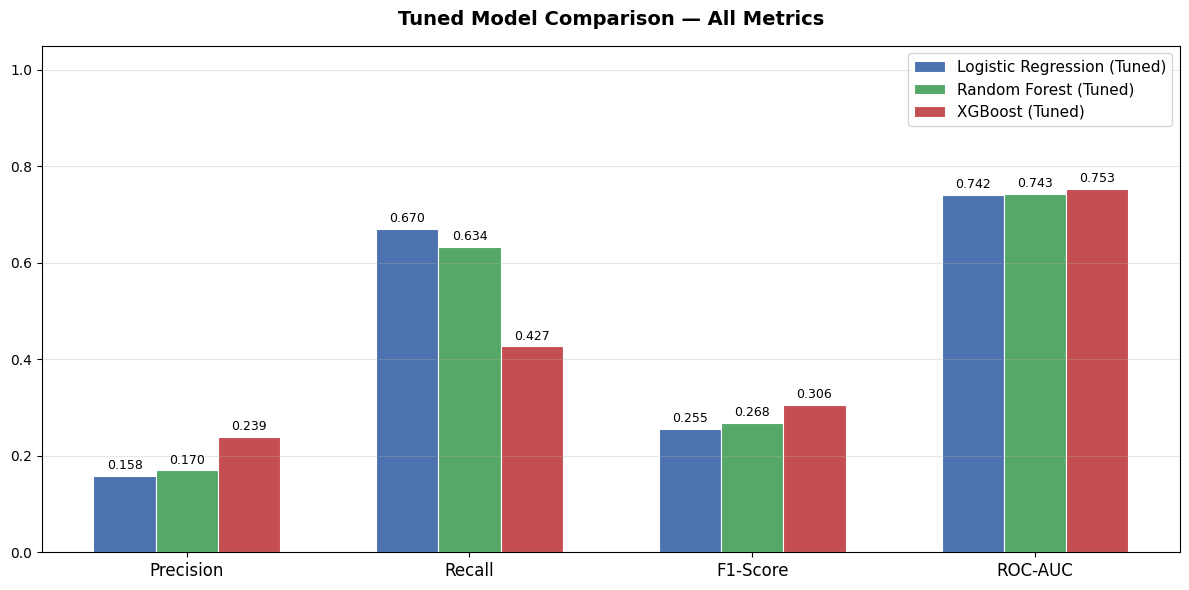

In [52]:
# --- Bar Chart: All Metrics Side-by-Side ---
fig, ax = plt.subplots(figsize=(12, 6))

metrics = ['Precision', 'Recall', 'F1-Score', 'ROC-AUC']
models = comparison_df.index.tolist()
x = np.arange(len(metrics))
width = 0.22

colors = ['#4C72B0', '#55A868', '#C44E52']

for i, model in enumerate(models):
    values = [comparison_df.loc[model, m] for m in metrics]
    bars = ax.bar(x + i * width, values, width, label=model, color=colors[i], edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_title('Tuned Model Comparison — All Metrics', fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

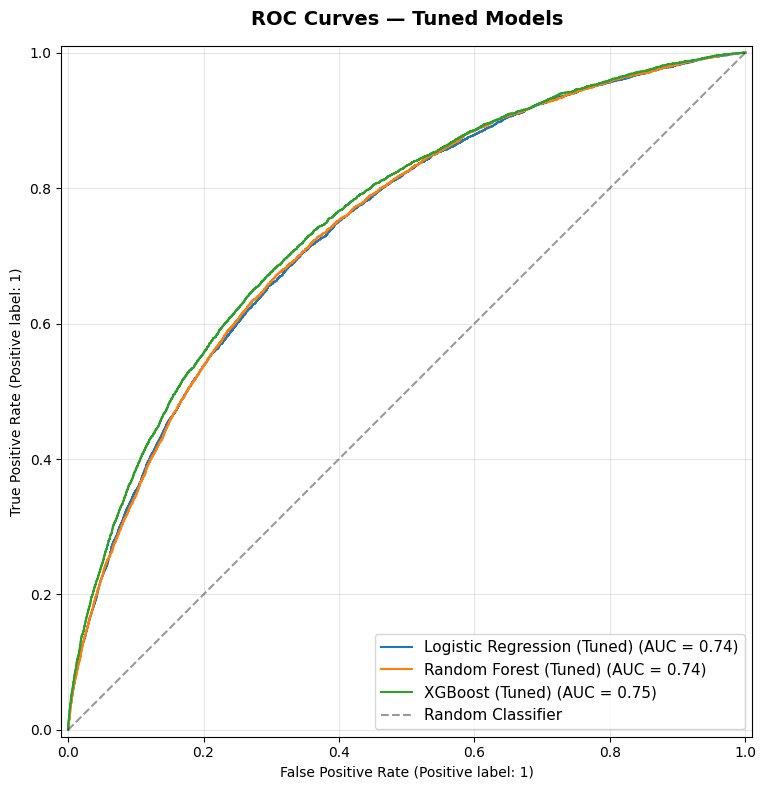

In [53]:
# --- ROC Curves: Tuned Models ---
fig, ax = plt.subplots(figsize=(8, 8))

tuned_models = {
    'Logistic Regression (Tuned)': lr_search.best_estimator_,
    'Random Forest (Tuned)': rf_search.best_estimator_,
    'XGBoost (Tuned)': xgb_search.best_estimator_
}

for name, model in tuned_models.items():
    RocCurveDisplay.from_estimator(model, X_val_scaled, y_val, ax=ax, name=name)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random Classifier')
ax.set_title('ROC Curves — Tuned Models', fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=11, loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 11. All Best Parameters Summary

In [54]:
print('=' * 70)
print(' COMPLETE BEST PARAMETERS REFERENCE')
print('=' * 70)

all_searches = {
    'Logistic Regression': lr_search,
    'Random Forest': rf_search,
    'XGBoost': xgb_search
}

for model_name, search in all_searches.items():
    print(f'\n--- {model_name} (CV ROC-AUC: {search.best_score_:.4f}) ---')
    params = search.best_params_
    for key, value in params.items():
        if isinstance(value, float):
            print(f'   {key:<22} = {value:.6f}')
        else:
            print(f'   {key:<22} = {value}')

 COMPLETE BEST PARAMETERS REFERENCE

--- Logistic Regression (CV ROC-AUC: 0.7374) ---
   C                      = 0.132929
   class_weight           = balanced
   max_iter               = 500
   penalty                = l1
   solver                 = liblinear

--- Random Forest (CV ROC-AUC: 0.7393) ---
   class_weight           = balanced
   max_depth              = 8
   max_features           = log2
   min_samples_leaf       = 4
   min_samples_split      = 10
   n_estimators           = 152

--- XGBoost (CV ROC-AUC: 0.7484) ---
   colsample_bytree       = 0.885298
   gamma                  = 1.521570
   learning_rate          = 0.067464
   max_depth              = 5
   min_child_weight       = 1
   n_estimators           = 114
   scale_pos_weight       = 6.108908
   subsample              = 0.775735


## 12. Summary & Next Steps

### What We Did
- Tuned 3 models (Logistic Regression, Random Forest, XGBoost) using RandomizedSearchCV
- Used StratifiedKFold cross-validation to maintain class balance
- Compared tuned models on Precision, Recall, F1-Score, and ROC-AUC
- Checked for overfitting by comparing CV scores to validation scores

### Potential Next Steps
- Increase `N_ITER` for more thorough hyperparameter search
- Try additional models (LightGBM, CatBoost)
- Ensemble methods (stacking, blending)
- Feature selection to reduce dimensionality

Threshold Optimization

This notebook should be run **after `06_hyperparameter_tuning.ipynb`**.

Goal:
- Use the tuned XGBoost model
- Analyze different probability thresholds
- Compare Precision, Recall, F1
- Find the best threshold for business objectives


## 1. Generate Prediction Probabilities

Make sure these variables already exist from the previous notebook:

- `xgb_search`
- `X_test`
- `y_test`

In [55]:
best_xgb = xgb_search.best_estimator_

y_proba = best_xgb.predict_proba(X_val_scaled)[:, 1]

print("Prediction probabilities generated successfully.")


Prediction probabilities generated successfully.


## 2. Evaluate Multiple Thresholds

In [56]:
thresholds = np.arange(0.10, 0.91, 0.05)

results = []

for threshold in thresholds:

    y_pred = (y_proba >= threshold).astype(int)

    precision = precision_score(y_val, y_pred, zero_division=0)
    recall = recall_score(y_val, y_pred, zero_division=0)
    f1 = f1_score(y_val, y_pred, zero_division=0)

    results.append([threshold, precision, recall, f1])

threshold_df = pd.DataFrame(
    results,
    columns=["Threshold", "Precision", "Recall", "F1"]
)

threshold_df

,Threshold,Precision,Recall,F1
0,0.10,0.091464,0.972205,0.167198
1,0.15,0.103397,0.930514,0.186114
2,0.20,0.116874,0.877341,0.206270
3,0.25,0.131909,0.815710,0.227094
4,0.30,0.148631,0.744411,0.247788
5,0.35,0.167725,0.665055,0.267889
6,0.40,0.188423,0.588721,0.285477
7,0.45,0.212591,0.510775,0.300225
8,0.50,0.238814,0.426788,0.306258
9,0.55,0.265488,0.341793,0.298847


## 3. Best Threshold by F1 Score

In [57]:
best_row = threshold_df.loc[threshold_df['F1'].idxmax()]

print("Best Threshold Based on F1 Score")
print("="*50)
print(best_row)

Best Threshold Based on F1 Score
Threshold    0.500000
Precision    0.238814
Recall       0.426788
F1           0.306258
Name: 8, dtype: float64


## 4. Visualization

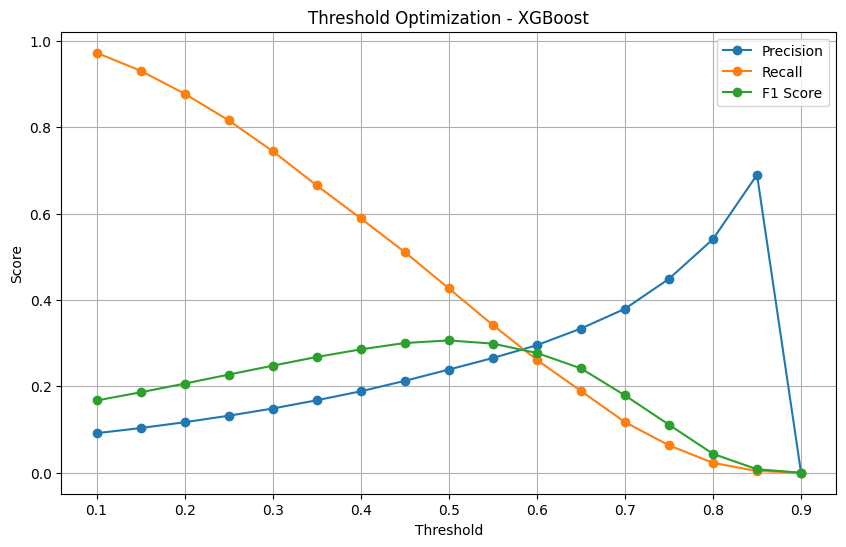

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(threshold_df['Threshold'], threshold_df['Precision'], marker='o', label='Precision')
plt.plot(threshold_df['Threshold'], threshold_df['Recall'], marker='o', label='Recall')
plt.plot(threshold_df['Threshold'], threshold_df['F1'], marker='o', label='F1 Score')

plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Threshold Optimization - XGBoost')
plt.grid(True)
plt.legend()

plt.show()

## 5. Confusion Matrix Using Best Threshold

Best Threshold = 0.50


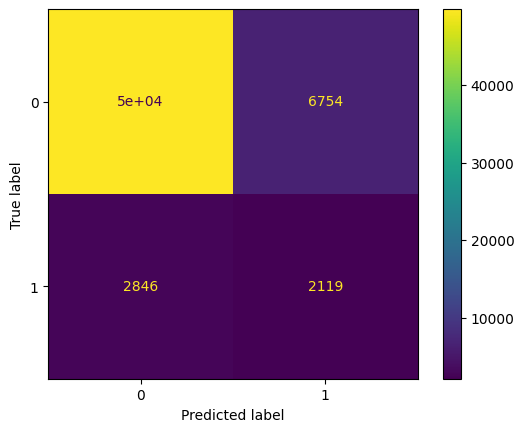

In [59]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

best_threshold = best_row['Threshold']

y_pred_best = (y_proba >= best_threshold).astype(int)

cm = confusion_matrix(y_val, y_pred_best)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

print(f"Best Threshold = {best_threshold:.2f}")